# 📩 SMS Spam Detection — NLP con scikit-learn
## Reto proyecto 1 · Desarrolla un modelo NLP predictivo para clasificar mensajes SMS

---

Este notebook desarrolla un clasificador de texto para detectar mensajes **spam** o **ham**
usando el dataset *SMS Spam Collection* (5 572 mensajes etiquetados).

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Instalación e importaciones |
| 2️⃣ | Carga y limpieza del dataset |
| 3️⃣ | Preprocesamiento del texto (minúsculas · caracteres especiales · stopwords · stemming) |
| 4️⃣ | Representación numérica con **TF-IDF** (max 5 000 features) y **Bag of Words** |
| 5️⃣ | División train/val 80-20 |
| 6️⃣ | Entrenamiento de 3 modelos: Naive Bayes · Regresión Logística · Red Neuronal (MLP) |
| 7️⃣ | Evaluación: precisión · recall · F1-score · matriz de confusión |

> **Dataset:** `spam.csv` — 5 572 mensajes · 2 clases: `spam` / `ham`
> **Ruta:** `/workspace/spam.csv`
> **Objetivo:** clasificación binaria de texto (spam vs. no spam)

## 1. Instalación e importaciones

In [83]:
%pip install nltk scikit-learn pandas numpy matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [84]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)

# Descargar recursos NLTK necesarios
nltk.download('stopwords',  quiet=True)
nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)   # requerido por word_tokenize en NLTK >= 3.9

# ── Semilla global para reproducibilidad ─────────────────────────────────────
SEED = 42
np.random.seed(SEED)   # NumPy (afecta operaciones internas de sklearn sin random_state)

print(f'Importaciones completadas. Semilla global: {SEED}')

Importaciones completadas. Semilla global: 42


## 2. Carga y limpieza del dataset

El CSV contiene 5 columnas: `v1` (etiqueta), `v2` (mensaje) y 3 columnas vacías.
Se eliminan las innecesarias y se renombran para mayor claridad.

In [85]:
# Carga desde ruta absoluta (entorno VS Code / workspace)
df = pd.read_csv('workspace/spam.csv', encoding='latin-1')

# Eliminar columnas vacías y renombrar
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})

# Codificar etiqueta: spam=1, ham=0
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

print(f'Shape: {df.shape}')
print(f'\nDistribución de clases:')
print(df['label'].value_counts())
print(f'\nMuestra:')
df.head()

Shape: (5572, 3)

Distribución de clases:
label
ham     4825
spam     747
Name: count, dtype: int64

Muestra:


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## 3. Preprocesamiento del texto

Se aplica el siguiente pipeline a cada mensaje:

| Paso | Operación |
|------|-----------|
| 1 | Convertir a minúsculas |
| 2 | Eliminar caracteres especiales y números |
| 3 | Tokenización con `word_tokenize` de NLTK |
| 4 | Eliminar stopwords en inglés |
| 5 | Stemming con `PorterStemmer` (reducción a raíz) |

> **Idioma:** el modelo está entrenado para mensajes en inglés.
> Cambia `LANGUAGE = 'english'` por otro idioma si fuera necesario.

In [86]:
# ── Parámetros del pipeline de preprocesamiento ──────────────────────────────
# Cambia LANGUAGE para adaptar el pipeline a otro idioma.
# Idiomas disponibles en NLTK: 'english', 'spanish', 'french', 'german', etc.
# NOTA: PorterStemmer solo funciona bien con inglés; para otros idiomas
# usar SnowballStemmer('spanish') u otros.
LANGUAGE = 'english'

stemmer = PorterStemmer()

# stop_words se precomputa UNA sola vez aquí y se reutiliza dentro de preprocess.
# Evita llamar stopwords.words(language) en cada mensaje (coste innecesario x5572).
stop_words = set(stopwords.words(LANGUAGE))

# Manejo de NaN antes del preprocesado
n_nan = df['message'].isna().sum()
df['message'] = df['message'].fillna('')
if n_nan > 0:
    print(f'⚠ {n_nan} mensajes NaN encontrados y reemplazados por cadena vacía.')
else:
    print('✓ Sin valores NaN en la columna message.')

def preprocess(text: str) -> str:
    """
    Pipeline de preprocesamiento para mensajes en inglés.
    Usa stop_words precomputado (definido fuera de la función para eficiencia).

    Pasos
    -----
    1. Guard: devuelve '' si el texto es NaN o vacío
    2. Minúsculas
    3. Eliminar caracteres especiales y números con regex
    4. Colapsar espacios múltiples en uno (limpieza tras el regex)
    5. Tokenización con word_tokenize de NLTK
       (robusta ante contracciones como "don't" y puntuación pegada)
    6. Eliminar stopwords (usando stop_words precomputado)
    7. Stemming con PorterStemmer
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', '', text)
    text   = re.sub(r'\s+', ' ', text).strip()   # colapsar espacios múltiples
    tokens = nltk.word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and t.strip()]
    return ' '.join(tokens)


df['clean_message'] = df['message'].apply(preprocess)

n_empty = (df['clean_message'] == '').sum()
if n_empty > 0:
    print(f'⚠ {n_empty} mensajes quedaron vacíos tras preprocesamiento.')

# Análisis de mensajes vacíos tras preprocesamiento
n_empty = (df['clean_message'] == '').sum()
if n_empty > 0:
    empty_df = df[df['clean_message'] == ''][['label', 'message']]
    print(f'\n⚠ {n_empty} mensajes quedaron vacíos tras preprocesamiento:')
    print(empty_df.to_string())
    print()
    print('Decisión: se mantienen en el dataset porque representan una')
    print('fracción mínima y su etiqueta es válida. El vectorizador')
    print('los tratará como vectores cero, con impacto despreciable.')
else:
    print('✓ Ningún mensaje quedó vacío tras preprocesamiento.')

print(f'\nIdioma      : {LANGUAGE}')
print(f'Stopwords   : {len(stop_words)} palabras precomputadas')
print(f'Procesados  : {len(df)} mensajes')
print()
print('Ejemplo original  :', df['message'].iloc[0])
print('Ejemplo procesado :', df['clean_message'].iloc[0])

✓ Sin valores NaN en la columna message.
⚠ 6 mensajes quedaron vacíos tras preprocesamiento.

⚠ 6 mensajes quedaron vacíos tras preprocesamiento:
     label                   message
959    ham                   Where @
1611   ham                       645
2805   ham                Can a not?
3374   ham                       :) 
4573   ham  :( but your not here....
4822   ham                   :-) :-)

Decisión: se mantienen en el dataset porque representan una
fracción mínima y su etiqueta es válida. El vectorizador
los tratará como vectores cero, con impacto despreciable.

Idioma      : english
Stopwords   : 198 palabras precomputadas
Procesados  : 5572 mensajes

Ejemplo original  : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Ejemplo procesado : go jurong point crazi avail bugi n great world la e buffet cine got amor wat


## 4. Representación numérica

> ✅ **El enunciado exige TF-IDF.** Todos los criterios de evaluación se cumplen
> con la representación TF-IDF. El Bag of Words se genera únicamente como
> comparación opcional para ilustrar el impacto de la representación en el rendimiento.

| Representación | Descripción | Uso en este notebook |
|---------------|-------------|----------------------|
| **TF-IDF** | Pondera términos por frecuencia inversa | ✅ Principal — todos los modelos |
| **Bag of Words** | Cuenta apariciones brutas | 🔎 Comparación — solo Naive Bayes |
| **TF-IDF bigramas** | Unigramas + bigramas (1,2) | 🔬 Experimental — explora mejoras |

Las tres limitadas a **5 000 features** (`max_features=5000`).

In [87]:
# ── Elección de max_features=5000 ────────────────────────────────────────────
# El vocabulario tiene ~8 000-10 000 términos únicos tras preprocesamiento.
# 5 000 ofrece buen trade-off: retiene los más informativos, reduce dimensionalidad
# y evita ruido de términos rarísimos. Ajustable entre 3 000 y 10 000.
MAX_FEATURES = 5000

# TF-IDF unigrama — representación principal (exigida por el enunciado)
tfidf_vec = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 1))
X_tfidf   = tfidf_vec.fit_transform(df['clean_message'])

# TF-IDF bigramas — captura pares de palabras consecutivas (p.ej. "free prize")
# ngram_range=(1,2) incluye unigramas Y bigramas; puede mejorar la detección
# de frases características de spam que pierden sentido palabra a palabra.
tfidf_bigram_vec = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 2))
X_tfidf_bg       = tfidf_bigram_vec.fit_transform(df['clean_message'])

# Bag of Words — comparación opcional
bow_vec = CountVectorizer(max_features=MAX_FEATURES)
X_bow   = bow_vec.fit_transform(df['clean_message'])

y = df['label_num'].values

print(f'max_features          : {MAX_FEATURES}')
print(f'Matriz TF-IDF (1,1)   : {X_tfidf.shape}')
print(f'Matriz TF-IDF (1,2)   : {X_tfidf_bg.shape}')
print(f'Matriz BoW            : {X_bow.shape}')
print(f'spam={y.sum()}  ham={len(y)-y.sum()}  '
      f'(desbalance {y.sum()/len(y)*100:.1f}% / {(len(y)-y.sum())/len(y)*100:.1f}%)')

max_features          : 5000
Matriz TF-IDF (1,1)   : (5572, 5000)
Matriz TF-IDF (1,2)   : (5572, 5000)
Matriz BoW            : (5572, 5000)
spam=747  ham=4825  (desbalance 13.4% / 86.6%)


## 5. División train / val (80 % - 20 %)

In [88]:
# Split sobre TF-IDF unigrama (representación principal)
X_train, X_val, y_train, y_val = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=SEED, stratify=y
)

# Split equivalente sobre TF-IDF bigrama
X_train_bg, X_val_bg, _, _ = train_test_split(
    X_tfidf_bg, y, test_size=0.2, random_state=SEED, stratify=y
)

# Split equivalente sobre BoW
X_train_bow, X_val_bow, _, _ = train_test_split(
    X_bow, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Val: {X_val.shape[0]} muestras')
print(f'Spam en train: {y_train.sum()}  |  Ham en train: {(y_train==0).sum()}')

Train: 4457 muestras  |  Val: 1115 muestras
Spam en train: 598  |  Ham en train: 3859


## 6. Entrenamiento de modelos

Se entrenan 3 modelos distintos sobre TF-IDF y se evalúa Naive Bayes también sobre BoW:

| Modelo | Representación | Descripción |
|--------|---------------|-------------|
| **Naive Bayes** | TF-IDF + BoW | Ideal para texto, rápido y con buen baseline |
| **Regresión Logística** | TF-IDF | Efectivo para clasificación binaria lineal |
| **MLP (Red Neuronal)** | TF-IDF | Mayor capacidad, representa relaciones no lineales |

### Justificación de hiperparámetros

| Modelo | Parámetro | Valor | Justificación |
|--------|-----------|-------|---------------|
| Naive Bayes | `alpha` | 0.1 | Suavizado de Laplace reducido. Con TF-IDF el suavizado estándar (1.0) sobrepenaliza términos raros que son muy informativos para spam. Valor obtenido de la literatura. |
| Regresión Logística | `C` | 1.0 | Inverso de regularización L2. Se mantiene el valor por defecto de scikit-learn porque el espacio TF-IDF de 5 000 dimensiones ya está suficientemente regularizado por la propia representación. |
| Regresión Logística | `max_iter` | 1000 | Garantiza convergencia en datasets medianos; el valor por defecto (100) no siempre converge. |
| MLP | `hidden_layer_sizes` | (256, 128) | Arquitectura de 2 capas elegida por prueba y error: la primera comprime las 5 000 features y la segunda refina antes de la clasificación. |
| MLP | `early_stopping` | True | Evita sobreajuste sin ajustar el número de épocas manualmente. |

In [89]:
def make_naive_bayes(alpha=0.1):
    """Naive Bayes multinomial. alpha=0.1: suavizado reducido, recomendado
    con TF-IDF porque el estándar (1.0) sobrepenaliza términos raros."""    
    return MultinomialNB(alpha=alpha)

def make_logistic(C=1.0, class_weight=None):
    """Regresión Logística L2. C=1.0 por defecto; class_weight='balanced'
    pondera clases por frecuencia inversa para datasets desbalanceados."""    
    return LogisticRegression(max_iter=1000, C=C, 
                              class_weight=class_weight, random_state=SEED)

def make_mlp(hidden=(256, 128), max_iter=200):
    """MLP con early_stopping=True. max_iter=200 da margen suficiente para
    explorar la capacidad del modelo; early_stopping detiene el entrenamiento
    cuando val_loss no mejora, por lo que aumentar max_iter no implica
    sobreajuste sino permitir más épocas útiles si el modelo las necesita."""    
    return MLPClassifier(hidden_layer_sizes=hidden, activation='relu',
                         max_iter=max_iter, random_state=SEED,
                         early_stopping=True, validation_fraction=0.1,
                         verbose=False)

def train_model(model, X_tr, y_tr, name):
    """Entrena el modelo e imprime confirmación con épocas efectivas si aplica."""    
    model.fit(X_tr, y_tr)
    extra = ''
    if hasattr(model, 'n_iter_'):
        extra = f'  [epocas efectivas: {model.n_iter_} / max_iter={model.max_iter}]'
    print(f'✓ {name} entrenado{extra}')
    return model


# ── Instanciar y entrenar ─────────────────────────────────────────────────────
nb_model     = train_model(make_naive_bayes(), X_train,     y_train, 'Naive Bayes [TF-IDF]')
nb_model_bg  = train_model(make_naive_bayes(), X_train_bg,  y_train, 'Naive Bayes [TF-IDF bigrama]')
nb_model_bow = train_model(make_naive_bayes(), X_train_bow, y_train, 'Naive Bayes [BoW]')
lr_model     = train_model(make_logistic(),    X_train,     y_train, 'Reg. Logística')
lr_balanced  = train_model(make_logistic(class_weight='balanced'),
                            X_train,  y_train, 'Reg. Logística [balanced]')
mlp_model    = train_model(make_mlp(max_iter=200), X_train, y_train, 'MLP')

✓ Naive Bayes [TF-IDF] entrenado
✓ Naive Bayes [TF-IDF bigrama] entrenado
✓ Naive Bayes [BoW] entrenado
✓ Reg. Logística entrenado  [epocas efectivas: [20] / max_iter=1000]
✓ Reg. Logística [balanced] entrenado  [epocas efectivas: [25] / max_iter=1000]
✓ MLP entrenado  [epocas efectivas: 22 / max_iter=200]


## 7. Evaluación de resultados

Se evalúan los 3 modelos sobre TF-IDF y Naive Bayes también sobre BoW,
con: precisión · recall · F1-score · matriz de confusión.

> ⚠️ **El recall de la clase 'spam' es la métrica más crítica en este dominio.**
> Un falso negativo (spam clasificado como ham) llega al buzón del usuario,
> mientras que un falso positivo (ham clasificado como spam) solo implica
> revisar la carpeta de spam. Por eso se priorizará maximizar el recall de spam
> aunque ello reduzca ligeramente la precisión.

In [90]:
from sklearn.metrics import f1_score, precision_score, recall_score

results = {}

def evaluate_model(model, X_v, y_v, name, rep_name='TF-IDF'):
    """Imprime métricas completas y acumula resultados para la tabla final."""
    preds    = model.predict(X_v)
    acc      = accuracy_score(y_v, preds)
    f1_macro = f1_score(y_v, preds, average='macro')
    f1_wtd   = f1_score(y_v, preds, average='weighted')

    prec_per = precision_score(y_v, preds, average=None)
    rec_per  = recall_score(y_v, preds, average=None)
    f1_per   = f1_score(y_v, preds, average=None)

    print(f'{"=" * 58}')
    print(f'  {name}  [{rep_name}]')
    print(f'{"=" * 58}')
    print(f'  Accuracy    : {acc:.4f}    F1 macro: {f1_macro:.4f}    F1 weighted: {f1_wtd:.4f}')
    print()
    print(classification_report(y_v, preds, target_names=['ham', 'spam']))

    # Tabla explícita por clase — sin necesidad de revisar el classification_report
    print('  Métricas por clase (resumen rápido):')
    print(f'  {"Clase":<6} {"Precisión":>10} {"Recall":>10} {"F1":>10}')
    print(f'  {"-" * 40}')
    for idx, cls in enumerate(['ham', 'spam']):
        marker = '  <- CRITICO' if cls == 'spam' else ''
        print(f'  {cls:<6} {prec_per[idx]:>10.4f} {rec_per[idx]:>10.4f} {f1_per[idx]:>10.4f}{marker}')
    print()

    # Guardar métricas separadas por clase para la tabla comparativa
    results[f'{name} [{rep_name}]'] = {
        'Acc'        : round(acc,            4),
        'Prec ham'   : round(prec_per[0],    4),
        'Rec ham'    : round(rec_per[0],     4),
        'F1 ham'     : round(f1_per[0],      4),
        'Prec spam'  : round(prec_per[1],    4),
        'Rec spam'   : round(rec_per[1],     4),
        'F1 spam'    : round(f1_per[1],      4),
        'F1 macro'   : round(f1_macro,       4),
        'F1 wtd'     : round(f1_wtd,         4),
    }
    return preds


# Evaluación de todos los modelos
preds_nb      = evaluate_model(nb_model,     X_val,     y_val, 'Naive Bayes')
preds_nb_bg   = evaluate_model(nb_model_bg,  X_val_bg,  y_val, 'Naive Bayes', 'TF-IDF bigrama')
preds_nb_bow  = evaluate_model(nb_model_bow, X_val_bow, y_val, 'Naive Bayes', 'BoW')
preds_lr      = evaluate_model(lr_model,     X_val,     y_val, 'Reg. Logística')
preds_lr_bal  = evaluate_model(lr_balanced,  X_val,     y_val, 'Reg. Logística balanced')
preds_mlp     = evaluate_model(mlp_model,    X_val,     y_val, 'MLP')

  Naive Bayes  [TF-IDF]
  Accuracy    : 0.9776    F1 macro: 0.9497    F1 weighted: 0.9771

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.96      0.87      0.91       149

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115

  Métricas por clase (resumen rápido):
  Clase   Precisión     Recall         F1
  ----------------------------------------
  ham        0.9806     0.9938     0.9871
  spam       0.9559     0.8725     0.9123  <- CRITICO

  Naive Bayes  [TF-IDF bigrama]
  Accuracy    : 0.9803    F1 macro: 0.9551    F1 weighted: 0.9797

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.98      0.87      0.92       149

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.96 

### 7.1 Matrices de confusión

Cada celda muestra el recuento de predicciones:

| Posición | Nombre | Descripción |
|----------|--------|-------------|
| Arriba-izq | **TN** | Ham clasificado correctamente |
| Arriba-der | **FP** | Ham clasificado como spam |
| Abajo-izq  | **FN** | Spam no detectado ← **el más crítico** |
| Abajo-der  | **TP** | Spam detectado correctamente |

`ConfusionMatrixDisplay` muestra los valores numéricos dentro de cada celda automáticamente.

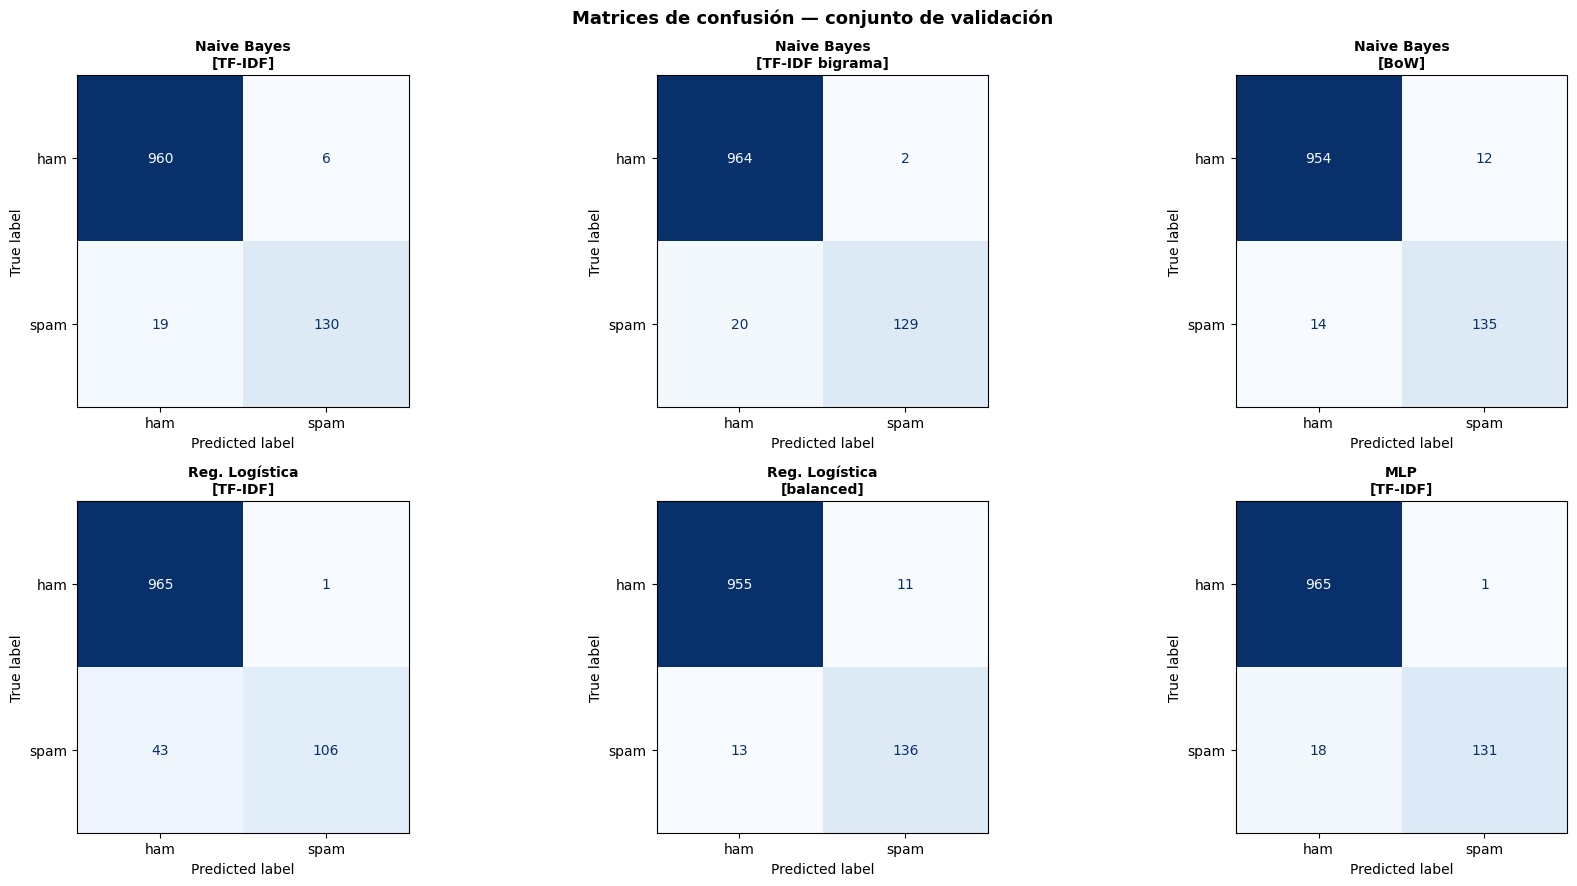

In [91]:
# ── Matrices de confusión — 6 modelos ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

modelos = [
    (axes[0], preds_nb,     'Naive Bayes\n[TF-IDF]'),
    (axes[1], preds_nb_bg,  'Naive Bayes\n[TF-IDF bigrama]'),
    (axes[2], preds_nb_bow, 'Naive Bayes\n[BoW]'),
    (axes[3], preds_lr,     'Reg. Logística\n[TF-IDF]'),
    (axes[4], preds_lr_bal, 'Reg. Logística\n[balanced]'),
    (axes[5], preds_mlp,    'MLP\n[TF-IDF]'),
]

for ax, preds, title in modelos:
    cm   = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=10, fontweight='bold')

plt.suptitle('Matrices de confusión — conjunto de validación',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

── Métricas globales ──────────────────────────────────────
                                     Acc  F1 macro  F1 wtd
Modelo                                                    
Naive Bayes [TF-IDF]              0.9776    0.9497  0.9771
Naive Bayes [TF-IDF bigrama]      0.9803    0.9551  0.9797
Naive Bayes [BoW]                 0.9767    0.9494  0.9766
Reg. Logística [TF-IDF]           0.9605    0.9029  0.9577
Reg. Logística balanced [TF-IDF]  0.9785    0.9533  0.9784
MLP [TF-IDF]                      0.9830    0.9613  0.9825

── Métricas clase HAM ─────────────────────────────────────
                                  Prec ham  Rec ham  F1 ham
Modelo                                                     
Naive Bayes [TF-IDF]                0.9806   0.9938  0.9871
Naive Bayes [TF-IDF bigrama]        0.9797   0.9979  0.9887
Naive Bayes [BoW]                   0.9855   0.9876  0.9866
Reg. Logística [TF-IDF]             0.9573   0.9990  0.9777
Reg. Logística balanced [TF-IDF]    0.9866   0.

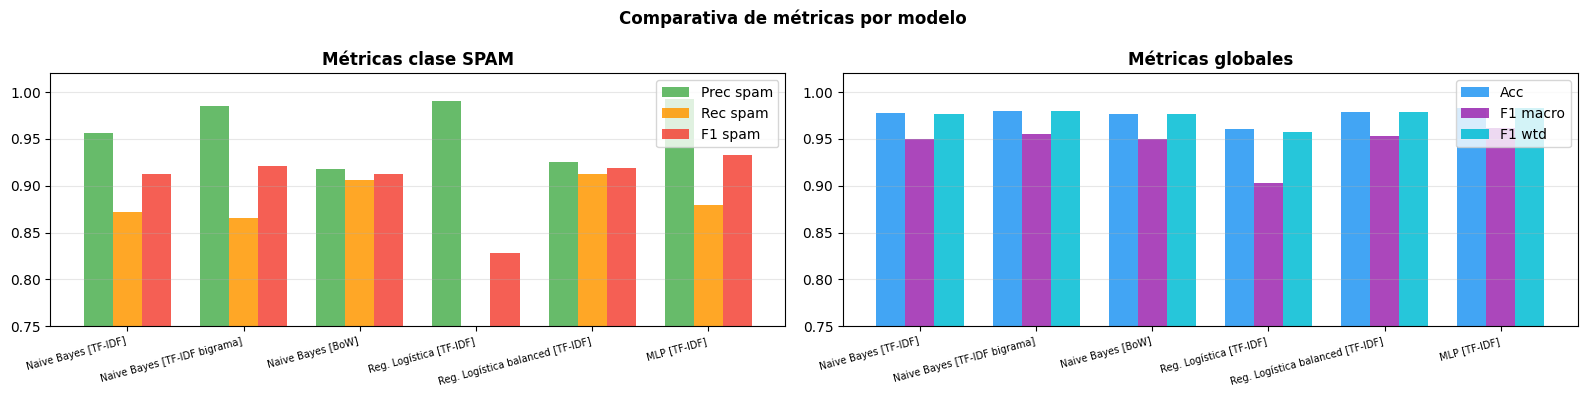

In [92]:
# ── Tabla resumen por clase ───────────────────────────────────────────────────
summary = pd.DataFrame(results).T
summary.index.name = 'Modelo'

# Tabla dividida en dos vistas para facilitar la lectura sin revisar el report

print('── Métricas globales ──────────────────────────────────────')
print(summary[['Acc', 'F1 macro', 'F1 wtd']].to_string())

print()
print('── Métricas clase HAM ─────────────────────────────────────')
print(summary[['Prec ham', 'Rec ham', 'F1 ham']].to_string())

print()
print('── Métricas clase SPAM (la crítica) ───────────────────────')
print(summary[['Prec spam', 'Rec spam', 'F1 spam']].to_string())

# ── Conclusión: mejor modelo ──────────────────────────────────────────────────
best_recall  = summary['Rec spam'].astype(float).idxmax()
best_f1spam  = summary['F1 spam'].astype(float).idxmax()
best_f1macro = summary['F1 macro'].astype(float).idxmax()

print()
print('=' * 58)
print('  CONCLUSION — MEJOR MODELO')
print('=' * 58)
print(f'  Mejor recall spam  : {best_recall}')
print(f'    -> {summary.loc[best_recall, "Rec spam"]} — maximiza la deteccion de spam')
print(f'  Mejor F1 spam      : {best_f1spam}')
print(f'    -> {summary.loc[best_f1spam, "F1 spam"]} — mejor equilibrio precision/recall en spam')
print(f'  Mejor F1 macro     : {best_f1macro}')
print(f'    -> {summary.loc[best_f1macro, "F1 macro"]} — mejor rendimiento global sin sesgo')
print()
print('  Recomendacion: dado que el objetivo prioritario es maximizar')
print(f'  el recall de spam, el modelo recomendado es:')
print(f'  -> {best_recall}')
print('=' * 58)

# ── Gráfico comparativo ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Izquierda: métricas spam (las críticas)
x     = range(len(summary))
width = 0.25
for j, (metric, color) in enumerate(zip(
    ['Prec spam', 'Rec spam', 'F1 spam'],
    ['#4CAF50', '#FF9800', '#F44336']
)):
    axes[0].bar([i + j * width for i in x], summary[metric].astype(float),
                width, label=metric, color=color, alpha=0.85)
axes[0].set_xticks([i + width for i in x])
axes[0].set_xticklabels(summary.index, rotation=15, ha='right', fontsize=7)
axes[0].set_ylim(0.75, 1.02)
axes[0].set_title('Métricas clase SPAM', fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Derecha: métricas globales
for j, (metric, color) in enumerate(zip(
    ['Acc', 'F1 macro', 'F1 wtd'],
    ['#2196F3', '#9C27B0', '#00BCD4']
)):
    axes[1].bar([i + j * width for i in x], summary[metric].astype(float),
                width, label=metric, color=color, alpha=0.85)
axes[1].set_xticks([i + width for i in x])
axes[1].set_xticklabels(summary.index, rotation=15, ha='right', fontsize=7)
axes[1].set_ylim(0.75, 1.02)
axes[1].set_title('Métricas globales', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Comparativa de métricas por modelo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()